In [2]:
import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import os
path = os.getcwd()

from neurolib.models.b import Model_b
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc
from neurolib.models import jacobian_aln as jac_aln
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [114]:
a = Model_b()
dur_pre = 0.
dur_post = 0.

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

max_it = 1
tol = 1e-30
incl_step = int(1. + a.params.duration/a.params.dt)
test_step = 1e-12

[[[ 0.         12.08206743 22.0010157  31.98906506 33.33652566
   24.67108811 14.04860591]]]


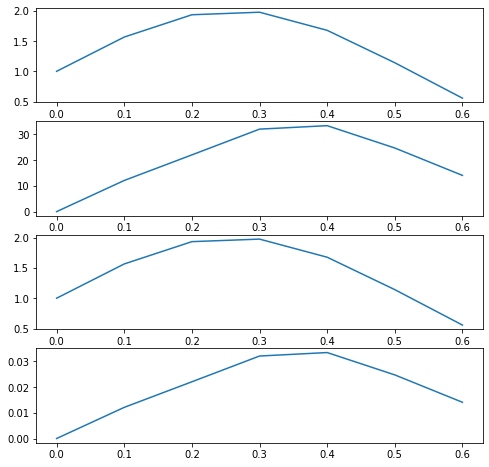

In [132]:
dur = 0.6

a.params.duration = dur

target = a.getZeroTarget()
control1 = a.getZeroControl()

control1[0,0,:] += 1.
control1[0,0,:] += np.sin(6.*np.arange(0,dur+a.params.dt,a.params.dt))

a.run(control=control1)

target[:,0,:] = a.rates_exc[:,:]
print(target)

fig, axes = plt.subplots(4, figsize=(8, 8))
axes[0].plot(a.t, control1[0,0,:])
axes[1].plot(a.t, a.state["rates_exc"][0,:])
axes[2].plot(a.t, a.state["mufe"][0,:])
axes[3].plot(a.t, a.state["sigmae_f"][0,:])

In [137]:
max_cntrl = 100. * 5.
start_step = 100.
cost_params = [1.0, 2.0, 0.0]

init_state_vars = np.array( [a.params.rates_exc_init, a.params.mufe_init] )
cost.setParams(cost_params[0], cost_params[1], cost_params[2])

control2 = a.getZeroControl()
#control2 += 1.

max_it = 100

A1_bestControlA, A1_bestStateA, A1_costA, runtime = a.A1(control2, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

set cost params
RUN  0 , total integrated cost =  125.66070730585682
RUN  1 , total integrated cost =  33.695696515084386
RUN  2 , total integrated cost =  9.566351804654389
RUN  3 , total integrated cost =  5.146412470829509
RUN  4 , total integrated cost =  3.437627197273878
RUN  5 , total integrated cost =  2.7739037249719996
RUN  6 , total integrated cost =  2.311326566615615
RUN  7 , total integrated cost =  2.011629183116814
RUN  8 , total integrated cost =  1.8034083273448556
RUN  9 , total integrated cost =  1.6824814229071237
RUN  10 , total integrated cost =  1.6081273599332477
RUN  11 , total integrated cost =  1.5667715568522107
RUN  12 , total integrated cost =  1.5426892930734684
RUN  13 , total integrated cost =  1.5293869877966741
RUN  14 , total integrated cost =  1.5218824116956242
RUN  15 , total integrated cost =  1.5178078566785214
RUN  16 , total integrated cost =  1.5155786982956463
RUN  17 , total integrated cost =  1.514388113705182
RUN  18 , total integrated c

[[[2.42089894e-05 2.41810197e-04 2.64019505e-03 2.97888033e-02
   9.78022039e-01 2.95530430e-02 0.00000000e+00]]]


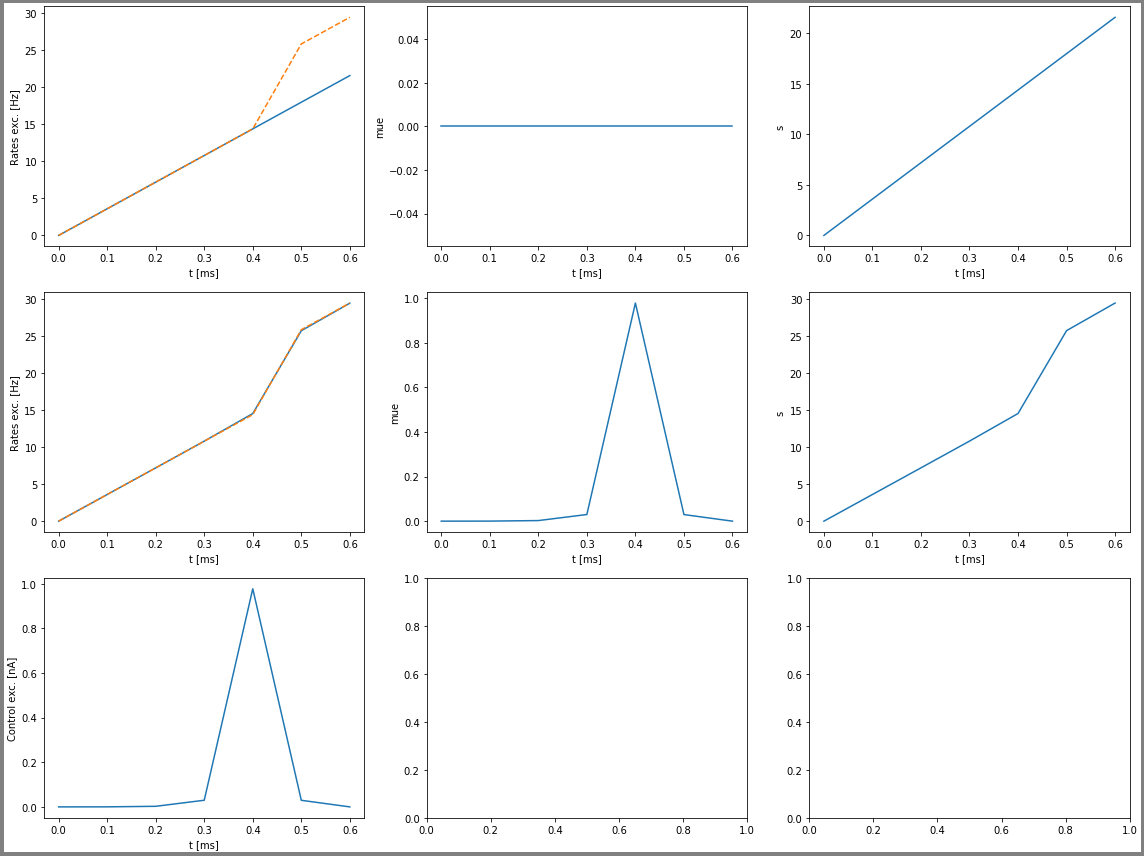

In [111]:
#1.5130136397445144
print(A1_bestControlA)
plotFunc.plot_control(a, A1_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'simp')

In [130]:
control3 = control2.copy()
control3[:,:,0] = A1_bestControlA[:,:,0]
control3[:,:,-1] = A1_bestControlA[:,:,-1]

max_it = 30

A2_bestControlA, A2_bestStateA, A2_costA, A2_runtimeA = a.A2(control3, target, max_iteration_ = max_it,
        tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
        max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

start ind =  1
RUN  0 , total integrated cost:  122.20988662695886
RUN  1 , total integrated cost:  13.069890921878365
RUN  2 , total integrated cost:  1.5284438095477781
RUN  3 , total integrated cost:  1.512995903000632
change helped, counter =  1
change helped, counter =  4
RUN  4 , total integrated cost:  1.5129955445512169
change helped, counter =  4
change helped, counter =  1
change helped, counter =  2
change helped, counter =  2
RUN  5 , total integrated cost:  1.5129955445492544
change helped, counter =  4
change helped, counter =  2
change helped, counter =  2
RUN  6 , total integrated cost:  1.5129955445482157
change helped, counter =  2
change helped, counter =  4
change helped, counter =  1
RUN  7 , total integrated cost:  1.5129955445482157
Control only changes marginally.
RUN  8 , total integrated cost:  1.5129955445482157
Improved over  8  iterations by  99  percent.


[[[0.01687308 0.02620633 0.05178694 0.11909763 0.36831842 0.09520468
   0.        ]]]


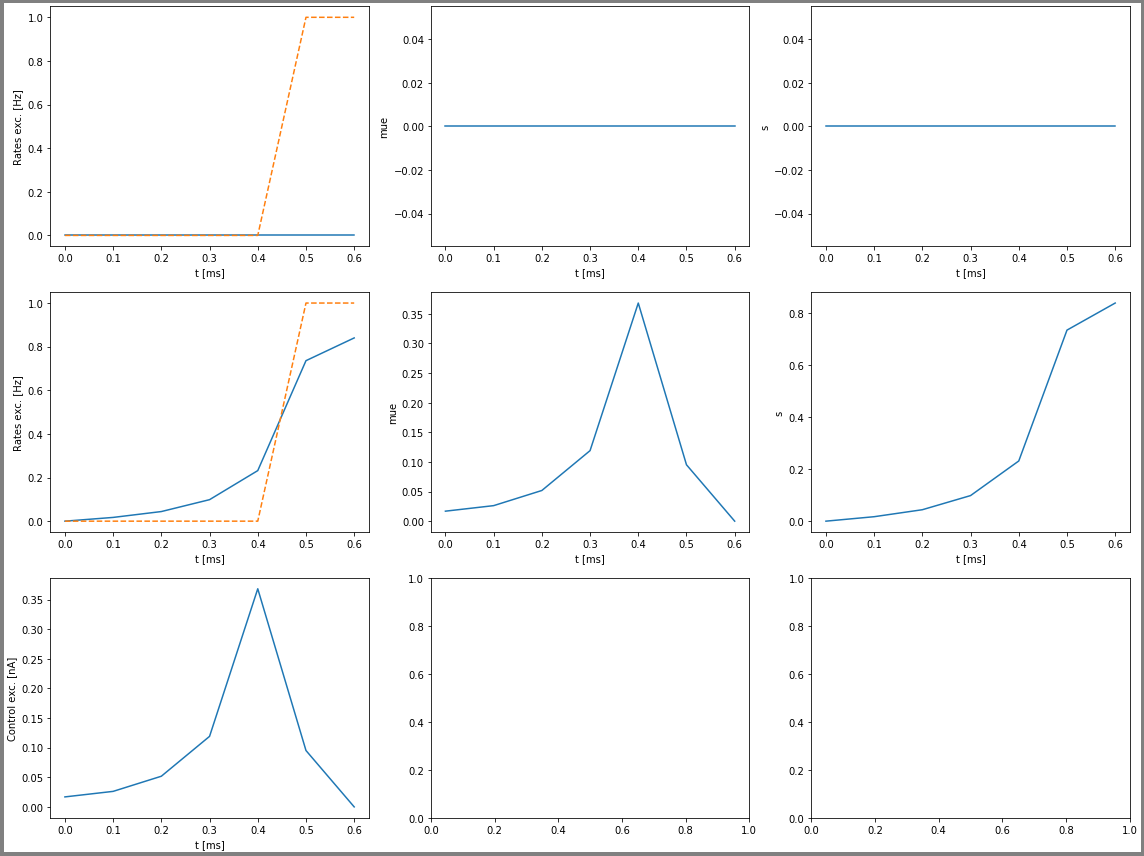

In [106]:
print(A2_bestControlA)
plotFunc.plot_control(a, A2_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'a2simp')

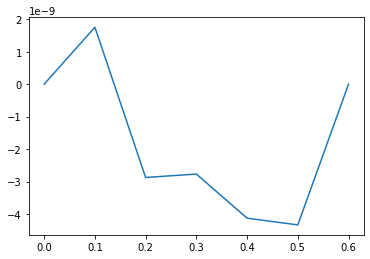

In [131]:
diff = A2_bestControlA[0,0,:] - A1_bestControlA[0,0,:]

plt.plot(a.t, diff)
plt.show()

(350, 64, 2)


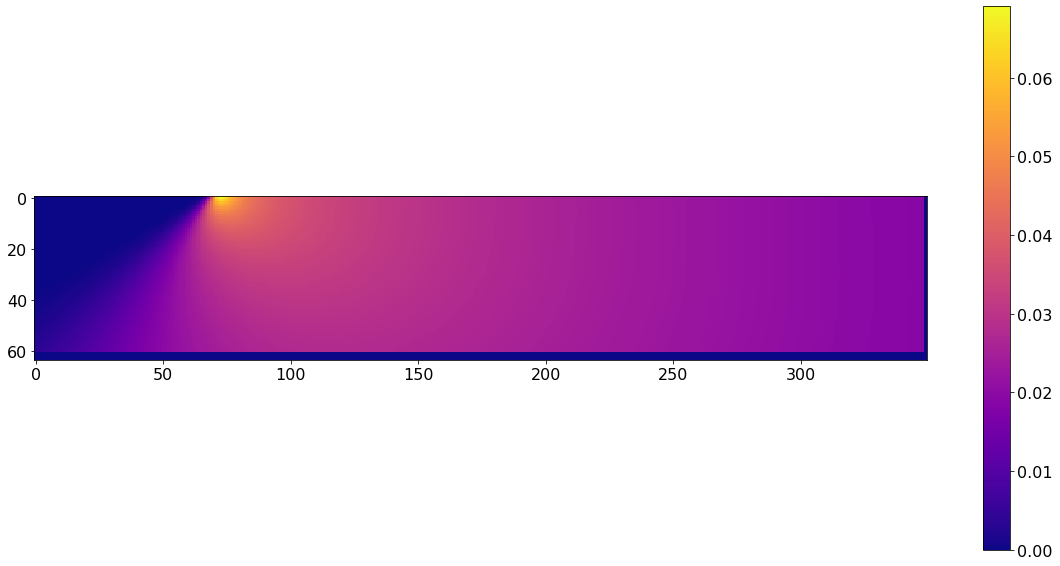

In [332]:
gradient_r = np.zeros(( len(aln.params.Irange), len(aln.params.sigmarange), 2 ))

sigma = aln.params.sigmarange[0]
mu = aln.params.Irange[0]

for sigma in range(len(aln.params.sigmarange)-3):
    for mu in range(len(aln.params.Irange)-1):
        res0 = jac_aln.der_mu(aln, aln.params.sigmarange[sigma], aln.params.Irange[mu], 0, aln.params.precalc_r)
        res1 = jac_aln.der_sigma(aln, aln.params.sigmarange[sigma], aln.params.Irange[mu], 0, aln.params.precalc_r)
        gradient_r[mu, sigma, 0] = res0
        gradient_r[mu, sigma, 1] = res1
        


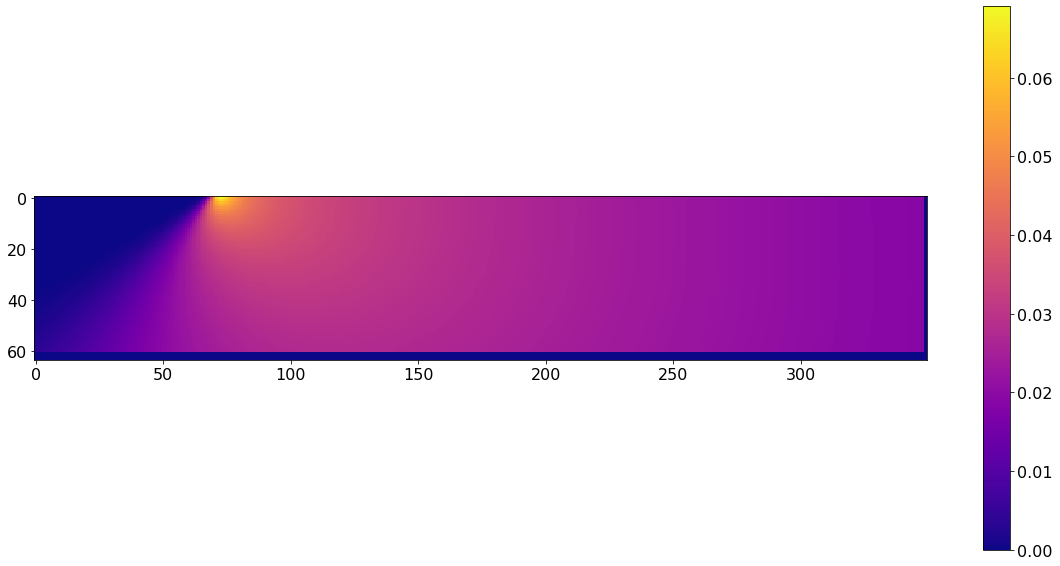

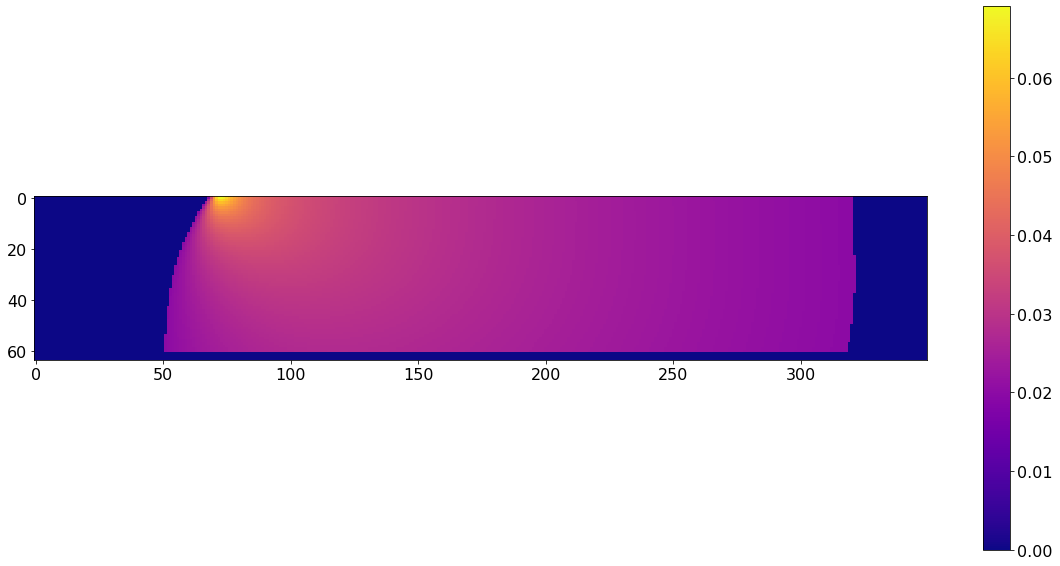

In [336]:
plt.figure(figsize=(20,10))
plt.imshow(gradient_r[:,:,0].T)
plt.colorbar()
plt.show()

threshold = 0.02
large_g = gradient_r.copy()
large_g[large_g < threshold] = 0

plt.figure(figsize=(20,10))
plt.imshow(large_g[:,:,0].T)
plt.colorbar()
plt.show()